In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Darshi\Downloads\retail_discountroi_dataset\Superstore.csv", encoding="latin1")
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

(9994, 21)

In [2]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df.duplicated().sum() #Checking for duplicate rows

np.int64(0)

In [6]:
df['Category'].unique() #Checking for unique values in categorical columns to catch any inconsistent labels

<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [7]:
df['Sub-Category'].unique()

<ArrowStringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

In [8]:
df['Region'].unique()

<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

In [9]:
df['Segment'].unique()

<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [10]:
#No duplicates found, labels are consistent in each categorical column

In [11]:
# Sanity check: are negative-profit orders associated with high discounts, as expected?
df[df['Profit'] < 0][['Discount', 'Sales', 'Profit', 'Sub-Category']].describe()

,Discount,Sales,Profit
count,1871.000000,1871.000000,1871.000000
mean,0.480887,250.511574,-83.448042
std,0.235080,715.067296,284.423422
min,0.100000,0.444000,-6599.978000
25%,0.200000,12.503000,-58.660950
50%,0.400000,71.088000,-18.088200
75%,0.700000,284.922000,-6.261500
max,0.800000,22638.480000,-0.089500


In [12]:
df[df['Profit'] < 0]['Discount'].mean()  # should be noticeably higher than overall average

np.float64(0.48088722608230894)

In [13]:
#Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [14]:
#Check for negative/zero sales that might be data errors (not just returns)
df[df['Sales'] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [15]:
#Profit margin
df['Profit Margin'] = df['Profit'] / df['Sales']

#Discount bucket (for easier grouping/visualization)
def discount_bucket(d):
    if d == 0: return "0%"
    elif d <= 0.10: return "1-10%"
    elif d <= 0.20: return "11-20%"
    elif d <= 0.30: return "21-30%"
    else: return "31%+"

df['Discount Bucket'] = df['Discount'].apply(discount_bucket)

#Time fields
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.to_period('M')

#Flag unprofitable orders
df['Is Unprofitable'] = df['Profit'] < 0
unprofitable_count = df['Is Unprofitable'].sum()
unprofitable_pct = df['Is Unprofitable'].mean()
unprofitable_total_loss = df[df['Is Unprofitable']]['Profit'].sum()

print(f"{unprofitable_count} orders ({unprofitable_pct:.1%}) are unprofitable, totaling ${abs(unprofitable_total_loss):,.0f} in losses")

1871 orders (18.7%) are unprofitable, totaling $156,131 in losses


In [16]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Discount Bucket,Order Year,Order Month,Is Unprofitable
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600,0%,2016,2016-11,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000,0%,2016,2016-11,False
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700,0%,2016,2016-06,False
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000,31%+,2015,2015-10,True
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125,11-20%,2015,2015-10,False


In [17]:
#EXPLORATORY ANALYSIS

In [18]:
import matplotlib.pyplot as plt

sub_cat_summary = df.groupby('Discount Bucket').agg(
    avg_margin=('Profit Margin', 'mean'),
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum'),
    order_count=('Order ID', 'nunique')
).reset_index()
sub_cat_summary['weighted_margin'] = sub_cat_summary['total_profit'] / sub_cat_summary['total_sales']
sub_cat_summary

,Discount Bucket,avg_margin,total_sales,total_profit,order_count,weighted_margin
0,0%,0.340160,1.087908e+06,320987.6032,2644,0.295050
1,1-10%,0.155792,5.436935e+04,9029.1770,89,0.166071
2,11-20%,0.174839,7.921529e+05,91756.2975,2436,0.115832
3,21-30%,-0.115481,1.032267e+05,-10369.2774,211,-0.100452
4,31%+,-0.914733,2.595435e+05,-125006.7786,888,-0.481641


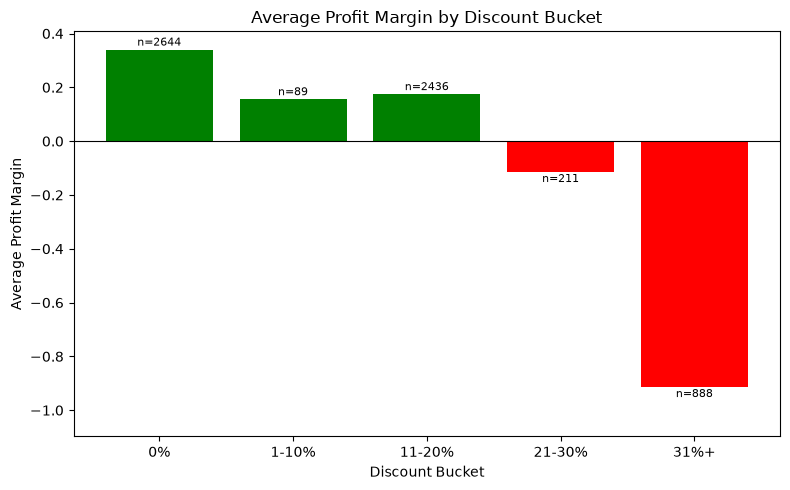

In [19]:
#To ensure buckets are in logical order, not alphabetical
bucket_order = ['0%', '1-10%', '11-20%', '21-30%', '31%+']
sub_cat_summary['Discount Bucket'] = pd.Categorical(
    sub_cat_summary['Discount Bucket'], categories=bucket_order, ordered=True
)
sub_cat_summary = sub_cat_summary.sort_values('Discount Bucket')

#Bar Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if m >= 0 else 'red' for m in sub_cat_summary['avg_margin']]

bars = ax.bar(sub_cat_summary['Discount Bucket'], sub_cat_summary['avg_margin'], color=colors)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit Margin by Discount Bucket')
ax.set_xlabel('Discount Bucket')
ax.set_ylabel('Average Profit Margin')
ax.set_ylim(min(sub_cat_summary['avg_margin']) * 1.2, max(sub_cat_summary['avg_margin']) * 1.2)

#Adding the order count as a label above/below each bar for transparency on sample size
for bar, count in zip(bars, sub_cat_summary['order_count']):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = 0.005 if height >= 0 else -0.005
    ax.text(bar.get_x() + bar.get_width()/2, height + offset, f'n={count}',
            ha='center', va=va, fontsize=8)

plt.tight_layout()
#plt.savefig(r"C:\Users\Darshi\Downloads\retail_discountroi_dataset/discount_bucket_margin.png", dpi=150)
plt.show()

In [20]:
cat_summary = df.groupby('Sub-Category').agg(
    avg_discount=('Discount', 'mean'),
    avg_margin=('Profit Margin', 'mean'),
    total_profit=('Profit', 'sum'),
    total_sales=('Sales', 'sum')
).sort_values('total_profit').reset_index()
cat_summary['weighted_margin'] = cat_summary['total_profit'] / cat_summary['total_sales']
cat_summary

,Sub-Category,avg_discount,avg_margin,total_profit,total_sales,weighted_margin
0,Tables,0.261285,-0.147727,-17725.4811,206965.5320,-0.085645
1,Bookcases,0.211140,-0.126640,-3472.5560,114879.9963,-0.030228
2,Supplies,0.076842,0.112039,-1189.0995,46673.5380,-0.025477
3,Fasteners,0.082028,0.299171,949.5182,3024.2800,0.313965
4,Machines,0.306087,-0.072026,3384.7569,189238.6310,0.017886
5,Labels,0.068681,0.429663,5546.2540,12486.3120,0.444187
6,Art,0.074874,0.251646,6527.7870,27118.7920,0.240711
7,Envelopes,0.080315,0.423140,6964.1767,16476.4020,0.422676
8,Furnishings,0.138349,0.137066,13059.1436,91705.1640,0.142404
9,Appliances,0.166524,-0.156869,18138.0054,107532.1610,0.168675


In [21]:
discount_summary = df.groupby('Discount').agg(
    avg_margin=('Profit Margin', 'mean'),
    weighted_margin=('Profit', 'sum'),
    order_count=('Order ID', 'nunique')
).reset_index()
discount_summary['weighted_margin'] = discount_summary['weighted_margin'] / df.groupby('Discount')['Sales'].sum().values

discount_summary

,Discount,avg_margin,weighted_margin,order_count
0,0.00,0.340160,0.295050,2644
1,0.10,0.155792,0.166071,89
2,0.15,0.034163,0.051490,51
3,0.20,0.176839,0.118151,2407
4,0.30,-0.115481,-0.100452,211
5,0.32,-0.174292,-0.164980,27
6,0.40,-0.222492,-0.198054,185
7,0.45,-0.454545,-0.454535,10
8,0.50,-0.549091,-0.348047,64
9,0.60,-0.689130,-0.894646,127


In [22]:
volume_check = df.groupby('Sub-Category').agg(
    avg_discount=('Discount', 'mean'),
    total_quantity=('Quantity', 'sum'),
    order_count=('Order ID', 'nunique')
).reset_index()

volume_check['avg_qty_per_order'] = volume_check['total_quantity'] / volume_check['order_count']
volume_check.corr(numeric_only=True)  # correlation between avg_discount and avg_qty_per_order

,avg_discount,total_quantity,order_count,avg_qty_per_order
avg_discount,1.000000,0.115251,0.075499,0.220503
total_quantity,0.115251,1.000000,0.997489,0.765112
order_count,0.075499,0.997489,1.000000,0.746498
avg_qty_per_order,0.220503,0.765112,0.746498,1.000000


In [23]:
region_summary = df.groupby('Region').agg(
    avg_discount=('Discount', 'mean'),
    avg_margin=('Profit Margin', 'mean'),
    total_profit=('Profit', 'sum')
).reset_index()

region_summary

,Region,avg_discount,avg_margin,total_profit
0,Central,0.240353,-0.104073,39706.3625
1,East,0.145365,0.167227,91522.7800
2,South,0.147253,0.163519,46749.4303
3,West,0.109335,0.219487,108418.4489


In [24]:
pivot = df.pivot_table(index='Sub-Category', columns='Discount Bucket', values='Profit', aggfunc='sum')
pivot

Discount Bucket,0%,1-10%,11-20%,21-30%,31%+
Sub-Category,,,,,
Accessories,35289.2539,NaN,6647.3818,NaN,NaN
Appliances,23183.7361,1086.0808,2497.8297,NaN,-8629.6412
Art,5380.6006,NaN,1147.1864,NaN,NaN
Binders,39314.4507,NaN,29417.8090,NaN,-38510.4964
Bookcases,6075.7117,NaN,1549.4937,-555.8726,-10541.8888
Chairs,21933.0961,7111.0119,4283.1750,-6737.1167,NaN
Copiers,35556.1349,NaN,17878.7148,NaN,2182.9752
Envelopes,4976.9844,NaN,1987.1923,NaN,NaN
Fasteners,652.2052,NaN,297.3130,NaN,NaN


In [25]:
# Estimate: profit lost specifically on orders discounted above the breakeven threshold AND unprofitable
threshold = 0.20 
over_threshold_losses = df[(df['Discount'] > threshold) & (df['Profit'] < 0)]
estimated_recoverable = over_threshold_losses['Profit'].sum()  # this will be negative

print(f"Estimated profit lost to over-discounting above {threshold:.0%}: ${abs(estimated_recoverable):,.0f}")

Estimated profit lost to over-discounting above 20%: $138,515


In [26]:
df.to_csv(r"C:\Users\Darshi\Downloads\retail_discountroi_dataset\superstore_cleaned.csv", index=False)